# PyOD: Anomaly Detection

In [7]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns, px

from feature_engine.outliers import Winsorizer, OutlierTrimmer
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD

## 1. Overview
An outlier is a data point that differs significantly from other observations. Outliers can cause serious problems in statistical analysis. Detecting outliers is more likely be an art rather than a science, therefore you need both quantitative and qualitative methods to identify outliers. However, there's no best rule for handling outliers. You need to ask yourself *Why are they outliers?* and *How can they affect your analyses?*.

### 1.1. Types of anomalies
- *Local anomalies*: Refers to the anomalies that deviant from their local neighbors. Imagine that there are 3 clusters in the dataset, in each cluster have some points that are different from other points in the same cluster. They are local anomalies.
- *Global anomlies*: The anomalies that far from normal data. Consider again 3 clusters in the dataset, if there are some points which far from all 3 clusters,that are called global anomalies.
- *Dependency anomalies*: refer to the data points that do not follow the dependency structure which normal data follow. Example salary covariates with education but anomalies do not.
- *Clustered anomalies*: is group of abnomalies, the data points are not scattered in space but appear in a group that are different from normal data

:::{image} ../image/chap_09/types_of_anomaly.png
:height: 220px
:align: center
:::

### 1.2. Approaches
Anomalies can be detected throught three types of Machine Learning approaches:
- *Unsupervised*: no label provided, the algorithm automatically identify outliers. This is the most popular scenario you may face in real-world problems.
- *Semi-supervised*: you provide to the algorithm normal data only, it will capture the general patterns and decide if any new data do not follow that pattern. Also known as novelty detection.
- *Supervised*: requires observations marked as outliers or not, can be solved as a binary classification problem. Rarely seen in reality.

### 1.3. Implementation

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, pd, plt, sns, px

from feature_engine.outliers import Winsorizer, OutlierTrimmer
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD

In [2]:
df_wine = pd.read_csv('../data/wine_quality.csv')
df_wine.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


#### Feature-engine
The simplest way to detect outliers is calculating statistics for a single variable and use them as thresholds to determine extreme values. There are four popular statistical ranges indicating normal data:

- Gaussian: $\mu-k\sigma<x<\mu+k\sigma$
    - $\mu$ is the mean
    - $\sigma$ is the standard deviation
    - $k$ (hyperparameter) is usually from $2$ to $3$
- IQR:  $Q_{0.25}-k\times\text{IQR}<x<Q_{0.75}+k\times\text{IQR}$
    - $Q_{0.25}$ and $Q_{0.75}$ are quantiles
    - $\text{IQR}=Q_{0.75}-Q_{0.25}$ is the [interquartile range]
    - $k$ (hyperparameter) is usually from $1.5$ to $3$
- MAD: $Q_{0.5}-k\times\text{MAD}<x<Q_{0.5}+k\times\text{MAD}$
    - $Q_{0.5}$ is the median
    - $\text{MAD}$ is the [median absolute deviation]
    - $k$ (hyperparameter) is usually from $3$ to $3.5$
- Quantiles: $Q_{k}<x<Q_{1-k}$
    - $Q_{k}$ and $Q_{1-k}$ are quantiles
    - $k$ (hyperparameter) is usually $0.05$ or $0.1$

[interquartile range]: https://en.wikipedia.org/wiki/Interquartile_range
[median absolute deviation]: https://en.wikipedia.org/wiki/Median_absolute_deviation

All four approaches are implemented in Feature-engine via [`Winsorizer`] (clipping outliers) or [`OutlierTrimmer`] (removing outliers). They share the same hyperparameters:
- `capping_method` the strategy for deciding extreme values, defaults to *gaussian*. Other options are *iqr*, *mad* and *quantiles*.
- `fold` the coefficient $k$ in theshold formulas, defaults to *0.05* for quantiles strategy and *3* for other strategies.
- `tail` in which side extreme values are considered outliers, defaults to *right*. Other options are *left* and *both*.

[`Winsorizer`]: https://feature-engine.readthedocs.io/en/latest/api_doc/outliers/Winsorizer.html
[`OutlierTrimmer`]: https://feature-engine.readthedocs.io/en/latest/api_doc/outliers/OutlierTrimmer.html

In [3]:
trimmer = OutlierTrimmer(capping_method='iqr', fold=1.5, tail='both', variables=['citric_acid'])
trimmer.fit(df_wine)
trimmer.right_tail_caps_

{'citric_acid': 0.5700000000000001}

:::{note}
Beside *clipping* and *trimming*, we can perform a log transformation on our feature. This dampends outlier effects.
:::

#### Scikit-learn
Scikit-learn distinguishes [outlier and novelty]. It provides a few algorithms for the task: [`IsolationForest`] [`LocalOutlierFactor`] [`OneClassSVM`] [`DBSCAN`].

[outlier and novelty]: https://scikit-learn.org/stable/modules/outlier_detection.html
[`IsolationForest`]: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
[`LocalOutlierFactor`]: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html
[`OneClassSVM`]: https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html
[`DBSCAN`]: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

In [4]:
model = DBSCAN(eps=9, min_samples=5)
(
    df_wine
    .assign(cluster=model.fit_predict(df_wine))
    .query('cluster == -1')
    .head(3)
)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,cluster
111,7.2,0.27,0.46,18.75,0.052,45.0,255.0,1.0000,3.04,0.52,8.9,5,-1
227,7.1,0.25,0.32,10.30,0.041,66.0,272.0,0.9969,3.17,0.52,9.1,6,-1
245,6.1,0.18,0.36,2.00,0.038,20.0,249.5,0.9923,3.37,0.79,11.3,6,-1


#### PyOD
Due to the limitations of Scikit-learn is anomaly detection task, we are going to use PyOD, a library with more than 40 algorithms (mainly unsupervised). It uses the same interface withy Scikit-learn so that Data Scientist can feel familiar with it, but the authors [don't recommend] using this library with Scikit-learn. With a pre-selected `contamination`, all algorithms aim to calculate a *raw anomaly scores* via the method [`decision_function()`] and then convert them into probabilities via the method [`predict_proba()`].

The list of algorithms can be found [here], divided into many categories such as linear, probabilistic and neighborhood-based. In the next sections, we learn these categories with the signature algorithms of each, how they calculate anomaly scores. To demonstrate the usage, we run an ECOD algorithm and visualize the results. ECOD and COPOD are the only algorithms having the ability to explain outliers.

[don't recommend]: https://pyod.readthedocs.io/en/latest/issues.html
[here]: https://pyod.readthedocs.io/en/latest/index.html#implemented-algorithms
[`decision_function()`]: https://pyod.readthedocs.io/en/latest/api_cc.html#pyod.models.base.BaseDetector.decision_function
[`predict_proba()`]: https://pyod.readthedocs.io/en/latest/api_cc.html#pyod.models.base.BaseDetector.predict_proba

In [9]:
import warnings; warnings.filterwarnings('ignore')

In [10]:
detector = ECOD(contamination=0.05)
detector.fit(df_wine)

score_outlier = detector.decision_function(df_wine)
prob_outlier = detector.predict_proba(df_wine)[:, 1]
flag_outlier = detector.predict(df_wine)

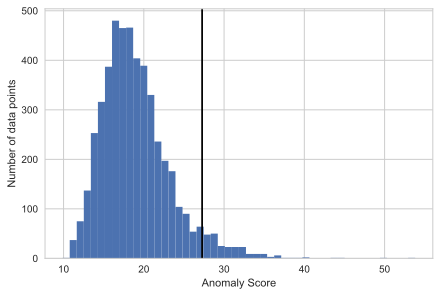

In [13]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(score_outlier, bins=50)
ax.axvline(detector.threshold_, c='k')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Number of data points')
plt.show()

In [14]:
reducer = PCA(n_components=3)
reducer.fit(df_wine)
projection = reducer.transform(df_wine)

df_projection = pd.DataFrame(data=projection, columns=['PC1', 'PC2', 'PC3'])
df_projection = df_projection.assign(flag_outlier=flag_outlier, prob_outlier=prob_outlier)

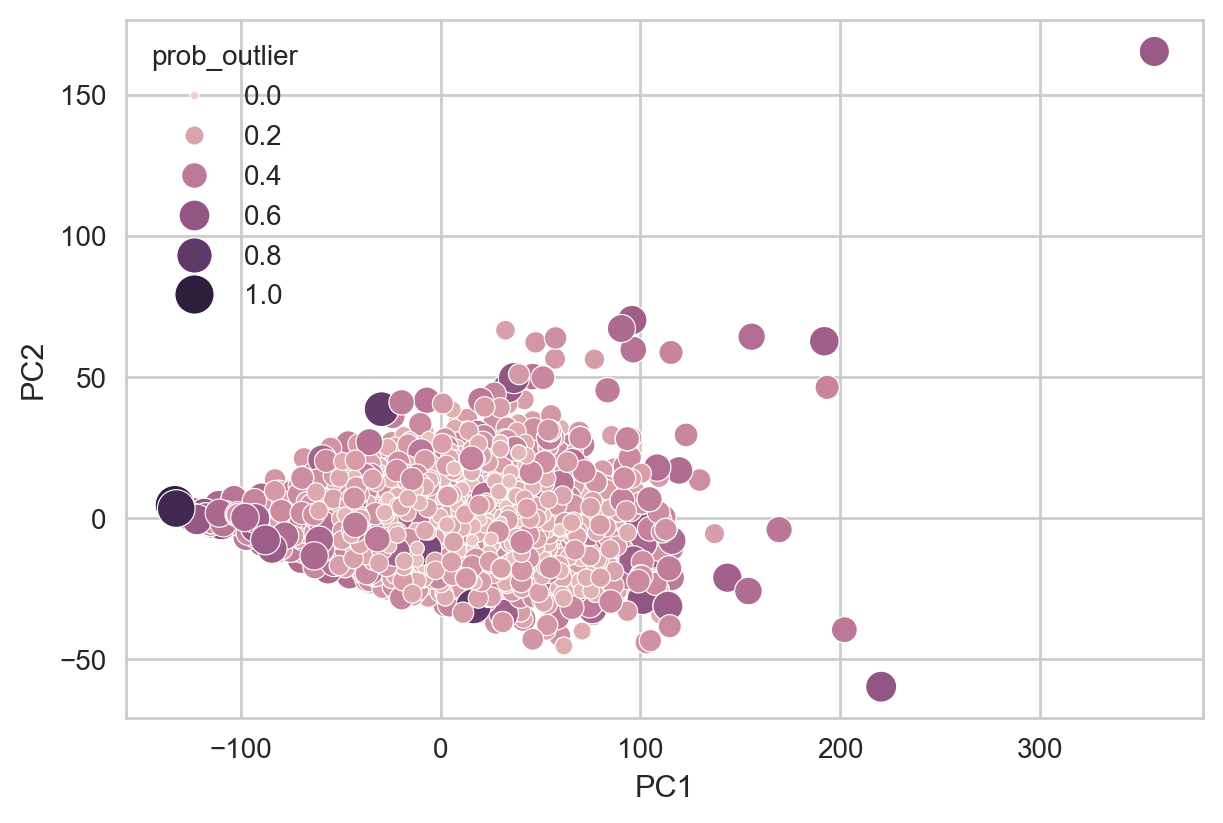

In [18]:
%config InlineBackend.figure_format = 'retina'

fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(
    data=df_projection,
    x='PC1',
    y='PC2',
    hue='prob_outlier',
    size='prob_outlier',
    sizes=(10, 200),
    ax=ax,
)
plt.show()

%config InlineBackend.figure_format = 'svg'

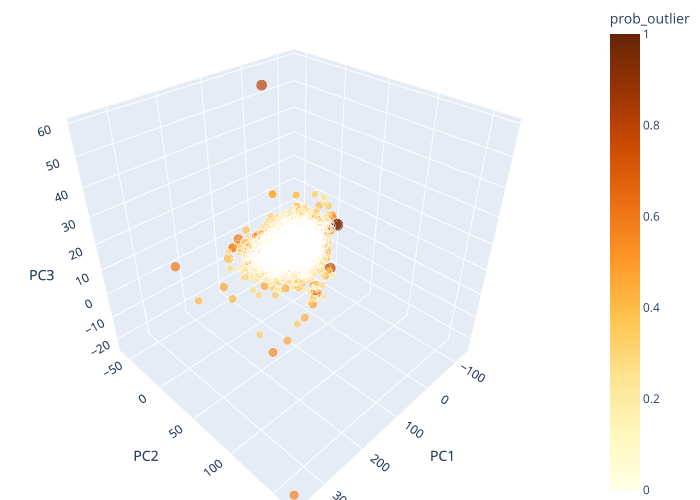

In [21]:
fig = px.scatter_3d(
    df_projection,
    x='PC1',
    y='PC2',
    z='PC3',
    color='prob_outlier',
    size='prob_outlier',
    color_continuous_scale='YlOrBr'
)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show(renderer='svg')

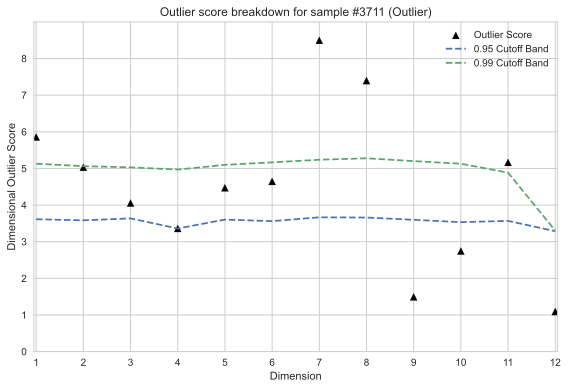

In [31]:
detector.explain_outlier(idx_outlier)

## 2. Linear models
These algorithms rely on linear models to compute outlier scores.

### 2.1. PCA
As far as we know, [Principal Component Analysis] is a technique which breaks down a matrix into vectors called principal components, then reconstruct the original data using only the first few most important components. This low dimensional space capture most variance in the data, meaning reconstructed points are very close to the principal components. However, as outliers differ from normal data, this statement may not be true. This insight is the key idea behind applying PCA in outlier detection: the outlier score for an observation will be obtained as the total of projected distances from that sample to all eigenvectors.

The implementation of this algorithm [`PCA`] has the following hyperparameters:
- `n_selected_components` the number of principal components involving in calculating outlier scores, defaults to *None* (use all components).
- `weighted` whether to use weighted sum in outlier score, where eigenvalues are the weights for their corresponding eigenvectors. Defaults to *True*.

[Principal Component Analysis]: https://en.wikipedia.org/wiki/Principal_component_analysis
[`PCA`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.pca.PCA

### 2.2. One-class SVM
In classification, [SVM] is originally designed for binary problems; the main idea is to learn a *hyperplane* that is able to separates two classes $1$ and $-1$ with maximum margin. If we treat the dataset as a single class, then SVM can be used to learn a function assigning $1$ to a small region that captures most of the data points and $-1$ elsewhere (outlier). This function only works if it was trained on normal data only - no outlier included, so this is considered a novelty detection method rather than outlier detection. There are two algorithms using this approach:
- [One-Class SVM] (OCSVM), aiming to learn a *hyperplane* separating *most* data point from the origin with maximum margin.
- [Support Vector Data Description] (SVDD), aiming to learn a *hypersphere* encompassing *most* data points with minimum volume.

The PyOD class [`OCSVM`] implements the first algorithm with the following hyperparameters:
- `nu` the parameter $\nu$ maintaining the allowance of misclassification (soft margin), being equivalant to $C$ in original SVM. Defaults to *0.5*, must be between *0* and *1*.
- `kernel` `gamma` `coef0` `degree` parameters of the kernel function, same usage as in original SVM.

[SVM]: https://en.wikipedia.org/wiki/Support_vector_machine
[One-Class SVM]: https://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.675.575&rep=rep1&type=pdf
[Support Vector Data Description]: https://link.springer.com/content/pdf/10.1023/B:MACH.0000008084.60811.49.pdf
[`OCSVM`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.ocsvm.OCSVM

## 3. Proximity-based
Also known as neighborhood-based, this approach assumes that outliers are far away from their neighbors. Most of them are computationally slow due to the calculation of distances.

### 3.1. KNN
The idea is very simple: aggregating distances from a data point to its $K$ nearest neighbors to get outlier score. The larger distance from a point to its neighbors, the more likely to be an outlier it is. The class [`KNN`] has the following hyperparameters:
- `n_neighbors` the number of neighbors considered ($K$), defaults to *5*.
- `method` the aggregate function to summarize outlier scores, defaults to *largest*. Other options are *mean* and *median*.
- `metric` the metric for distance computation. Defaults to *minkowski*, can also accepts many other metrics.

[`KNN`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.knn.KNN

### 3.2. Clustering-based
Not only DBSCAN, but any clustering algorithm can be utilized for anomaly detection - this is the main idea behind [Clustering Based Local Outlier Factor] (CBLOF). Let's say a clustering algorithm returns $K$ clusters for our dataset
$\text{C}=\{\mathcal{C}_1,\mathcal{C}_2,\dots,\mathcal{C}_K\}$
(sorted by decreasing cluster size), CBLOF aims to split them into small and large clusters. We denoted
$\text{LC}=\{\mathcal{C}_1,\mathcal{C}_2,\dots,\mathcal{C}_B\}$
the set of large clusters and
$\text{SC}=\{\mathcal{C}_{B+1},\mathcal{C}_{B+2},\dots,\mathcal{C}_K\}$
the set of small clusters. With the introduction of two parameters $\alpha$ and $\beta$, the determination of $\text{SC}$ and $\text{LC}$ must satisfy one of the two conditions:
- The ratio of observations in large clusters is at least $\alpha$ (usually $90\%$):
$|\mathcal{C}_1|+|\mathcal{C}_2|+\ldots+|\mathcal{C}_B|\geq\alpha N$
- All large clusters must be at least $\beta$ (usually $5$) times larger than small clusters:
$|\mathcal{C}_{B}|\geq\beta|\mathcal{C}_{B+1}|$

The anomaly score for a sample is then computed as the product of (1) the distance between the sample and the nearest centroid of a large cluster and (2) the size of the cluster it belongs to. The intuition behind the first term is we are viewing small clusters as groups of potential outliers, making their centroids carry no meaning. As the result, we use centroids of large clusters instead, but this distance will be very high for samples in small clusters. This leads us to the multiplication with the second term, it can be thought as a compensation for small clusters.

This algorithm is implemented via the class [`CBLOF`] with the hyperparameters:
- `clustering_estimator` the clustering algorithm to be used, defaults to *None* (using K-Means). It accepts an instance returned by Scikit-learn clustering classes.
- `n_clusters` the number of clusters, defaults to *8*.
- `alpha` the value of $\alpha$, defaults to *0.9*.
- `beta` the value of $\beta$, defaults to *5*.

[Clustering Based Local Outlier Factor]: https://citeseerx.ist.psu.edu/document?repid=rep1&type=pdf&doi=d8021847ed0e3f26b53416c2a254a85451ee5f1e
[`CBLOF`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.cblof.CBLOF

### 3.3. Local Outlier Factor
[Local Outlier Factor] (LOF) is a popular algorithm with the basic idea is to compare local density of an observation versus local density of its neighbors. The method for defining density is quite similar to DBSCAN. With a pre-selected value of $K$ (number of nearest neighbors), the algorithm follows these steps:
- *Step 1*: Define the *neighborhood radius* ($K$-distance in the original paper) for every sample $\mathbf{p}_n$ in the dataset being the distance from it to the $K^{th}$ nearest neighbor, denoted $r_n$.
- *Step 2*: Compute the so-called *reachability distance* ($\text{RD}_{nk}$) from a core point $\mathbf{p}_n$ to each of its neighbor $\mathbf{p}_k$ (for $k=1,2,\dots,K$). It is just the distance between the two points (denoted $d_{nk}$), but will be replaced with $r_k$ when they are too close.
<br>
For the example in image below, consider the core point $\mathbf{p}_n$ in red and its two nearest neighbors $\mathbf{p}_1$ and $\mathbf{p}_2$. Their neighborhood radiuses are the dotted circles, and the corresponding reachability distances are the thick lines. This calculation works as a smoothing strategy ensuring the distance being not too small, which produces fluctuations as we are going to use the inverse of it later.

$$\text{RD}_{nk}=\max(d_{nk},r_k)$$

:::{image} ../image/chap_09/local_outlier_factor.svg
:height: 250px
:align: center
:::
<br>

- *Step 3*: Compute the *local reachability density* for the core point $\mathbf{p}_n$ (denoted $\text{LRD}_n$) as the inverse of the average of its reachability distances. The key insight is: if a point is an outlier, then its average reachability distance will be large. Taking the inverse of such a distance will produce a low value, which resembles *local density*.

$$\text{LRD}_n=\left( \dfrac{1}{K}\sum\limits_{k=1}^{K}{\text{RD}_{nk}} \right)^{-1}$$

- *Step 4*: Compute the anomaly score for $\mathbf{p}_n$ using the formula below, which compares the local density of $\mathbf{p}_n$ with the local density of its neighbors. If this ratio is $>1$, then $\mathbf{p}_n$ lies in a region with lower density than its neighbors, meaning it is likely to be an outlier.

$$\text{LOF}_n=\frac{1}{K}\sum_{k=1}^{K}\frac{\text{LRD}_k}{\text{LRD}_n} $$

The implementation of this algorithm, [`LOF`], has two hyperparameters: `n_neighbors` `metric`. They share the same usage as in KNN.

[Local Outlier Factor]: https://en.wikipedia.org/wiki/Local_outlier_factor
[`LOF`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.lof.LOF

### 3.4. Connectivity-based
[Connectivity-based Outlier Factor] (COF) is an algorithm born to tackle the failure of Local Outlier Factor in identifying outliers that are close to low-density inliers. Like LOF, it also suits for finding local outliers. The algorithm contains these steps:

- *Step 1*: Consider a point $\mathbf{p}_n$ in the dataset, build a sequence $\mathbf{p}_1,\mathbf{p}_2,\dots,\mathbf{p}_K$ starting from it. In this sequence, each next point $\mathbf{p}_{k+1}$ is determined as the nearest neighbor of the previous one, $\mathbf{p}_k$.
- *Step 2*: Define *edge distance*, the distance between two consecutive points in this sequence: $e_k=d(\mathbf{p}_{k},\mathbf{p}_{k+1})$ for $k=1,2,\dots,K-1$.

:::{image} ../image/chap_09/connectivity_outlier_factor.svg
:height: 150px
:align: center
:::
<br>

- *Step 3*: Now we calculate the *average chaining distance* for $\mathbf{p}_n$ as a weighted sum of all edge distances. This formula assigns larger weights to earlier terms, so this value tends to be higher for an outlier. Can be considered equivalent to average reachability distance in LOF.

$$\text{ACD}_n=\sum_{k=1}^{K-1} \frac{2(K-k)}{k(K-1)}e_k $$

- *Step 4*: Compute the anomaly score for $\mathbf{p}_n$ as the ratio between the ACD of $\mathbf{p}_n$ and the average AVD of its $K$ nearest neighbors. This score is $>1$ indicates $\mathbf{p}_n$ must go a longer way to reach its neighbors, so it is more likely to be an outlier.

$$\text{LOF}_n=\text{ACD}_n\div\frac{1}{K}\sum_{k=1}^{K}\text{ACD}_k $$

The implementation [`COF`] has only a main hyperparameter, `n_neighbors`.

[Connectivity-based Outlier Factor]: https://www.cse.cuhk.edu.hk/~adafu/Pub/pakdd02.pdf
[`COF`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.cof.COF

## 4. Probabilistic
This method constructs the empirical distribution of the dataset then predict the tail probabilities of each given data point to determine its level of *extremeness*. This category introduces two noticeable algorithms, COPOD and ECOD, which are highly interpretable and hyperparameter-free.

### 4.1. Histogram-based
[Histogram-Based Outlier Score] (HBOS) is a simple algorithm makes use of *density histograms* (the $y$-axis represents probability, not sample count). The idea is that, if a data point is in a short bin, then there is a high chance that it is an outlier. This method is suitable for global and clustered outliers; and is computationally fast, especially when comparing with other algorithms on a large dataset.

It first constructs an univariate histogram for each variable $\mathbf{x}_d$ (for $d=1,2,\dots,D$). If any feature is categorical, then simply take sample ratio instead. Base on the insight about the correlation between *bin height* and *outlier chance*, we take the inverse of bin height then log-transform it to get a smoother outlier score for that bin. If we denote $h_{nd}$ the height of the bin that the feature $\mathbf{x}_d$ of the sample $\mathbf{p}_n$ falls into, then the outlier score of this sample is given by:

$$\text{HBOS}_n=\sum_{d=1}^D \log\frac{1}{h_{nd}}$$

In PyOD, the class [`HBOS`] has only one hyperparameter, `n_bins`. It defaults to *10* but can also be set to *auto*, leaving the algorithm determines the appropriate number of bins for each feature. Either way, HBOS faces a challenge: it is very sensitive to bin width (or number of bins, equivalent). In order to produce a stable outcome, a viable solution is to combine several models with different bin widths with the help of [`FeatureBagging`] or [`SUOD`].

[Histogram-Based Outlier Score]: https://www.goldiges.de/publications/HBOS-KI-2012.pdf
[`HBOS`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.hbos.HBOS
[`FeatureBagging`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.feature_bagging.FeatureBagging
[`SUOD`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.suod.SUOD

### 4.2. Copula-based
[Copula-based Outlier Detection] (COPOD) is a pretty new (2020) algorithm makes uses of [copula]. The underlying mathematics is quite complicated, so we can take away its key steps: (1) computing the empirical PDF at two tails for each feature, (2) computing empirical copula for each instance and (3) using the above results to calculate outlier score. This algorithm, implemented via [`COPOD`], is known for these advantages:
- Having no hyperparameter at all (which is important as we have no target function in a unsupervised problem)
- Being interpretable (a rare characteristic only seen in this algorithm and ECOD)
- Producing deterministic results, no randomness involved
- Top performance proved in the benchmark paper
- Being computationally efficient and scalable

[Copula-based Outlier Detection]: https://arxiv.org/pdf/2009.09463.pdf
[copula]: https://en.wikipedia.org/wiki/Copula_(probability_theory)
[`COPOD`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.copod.COPOD

### 4.3. ECOD
Empirical CDF for outlier detection, introduced in the paper [ECOD: Unsupervised Outlier Detection Using Empirical Cumulative Distribution Functions](https://arxiv.org/abs/2201.00382) (2022), is another new probabilistic algorithm, which works similarly to COPOD. It estimates an empirical CDF for each feature and then aggregate the tail probabilities for each sample to get the outlier score. The reason for using tail probabilities is beacause these regions imply high chance of containing outliers. At this point, we can see all three probabilistic algorithms presented in this section share the same idea. ECOD share the same strengths as COPOD and is implemented in the class [`ECOD`].

[Empirical CDF for outlier detection]: https://arxiv.org/pdf/2201.00382.pdf
[`ECOD`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.ecod.ECOD

## 5. Black-box
This group is a collection of Ensemble Learning and Deep Learning algorithms for outlier dectection.

### 5.1. Isolation Forest
The [Isolation Forest] algorithm bases on two properties of anomalous data: being *few* and *different*. In order to *isolate* such data points, the algorithm uses random partitioning, which can be expressed as binary tree structures with random splits. The construction of a so-called Isolation Tree, is thus very simple, by randomly selecting a feature as well as a cut point. This iterative process stops when each data point goes to a leaf node (we treat all same-value data point a single one). After a number of Isolation Trees have been built (called the Isolation Forest), the anomaly score is calculated basically as the average path to it over all trees $\bar{h}_n$ and is then normalized using the formula:

$$\begin{aligned}
\text{iForest}_n &= \exp\left( -\frac{\overline{h}_n}{c(N)} \right) \\
c(N) &= 2 (\log(N-1)+0.577) - \frac{2(N-1)}{N} \\
\end{aligned}$$

The implementation, [`IForest`] integrates random sampling when building each tree to make the algorithm more efficient. Its hyperparameters `n_estimators` `max_samples` `max_features` are the same as in Random Forest.

[Isolation Forest]: https://en.wikipedia.org/wiki/Isolation_forest
[`IForest`]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.iforest.IForest

### 5.2. Autoencoder
[Autoencoder] is a Deep Learning method using a collection of feedfoward layers which is divided into three parts: *encoder*, *bottleneck* and *decoder*. In the encoder, information will be *compressed* into the bottleneck, which is expected to store only general patterns and discard noises. As outliers *deviate* from the rest of the data, most of their information will not present in the bottleneck. In the decoder, the network reconstructs the original input, so the output layer always has the same size as the input.

Because data has been compressed, there will be lost information between the constructed data and the original data. These construction errors are usually higher for anomalous samples; so they will be used as anomaly scores. An Autoencoder can be designed any way you want, but is usually a symmetrical architecture as in the following image:

:::{image} ../image/chap_09/autoencoder.png
:height: 220px
:align: center
:::

PyOD has two implementations, [TensorFlow's] `AutoEncoder` and [PyTorch's] `AutoEncoder`. Their hyperparameters are roughly the same, but the PyTorch's version sets up the encoder and the decoder symmetrically, so the *code* will be a pair of identical layers.

[Autoencoder]: https://en.wikipedia.org/wiki/Autoencoder
[TensorFlow's]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.auto_encoder.AutoEncoder
[PyTorch's]: https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.auto_encoder_torch.AutoEncoder

## Resources
- arxiv.org - [ADBench: Anomaly Detection Benchmark](https://arxiv.org/pdf/2206.09426.pdf)
- madm.dfki.de - [Comparison of Unsupervised Anomaly Detection Techniques](https://madm.dfki.de/_media/theses/bachelorthesis-amer_2011.pdf)
- medium.com - [Local Outlier Factor (LOF) — Algorithm for outlier identification](https://towardsdatascience.com/local-outlier-factor-lof-algorithm-for-outlier-identification-8efb887d9843)
- medium.com - [Fast, Accurate Anomaly Detection Based on Copulas (COPOD)](https://towardsdatascience.com/fast-accurate-anomaly-detection-based-on-copulas-copod-3133ce9041fa)
- medium.com - [Replace Outlier Detection by Simple Statistics with ECOD](https://medium.com/geekculture/replace-outlier-detection-by-simple-statistics-with-ecod-f95a7d982f79)